In [1]:
import os
os.makedirs('datasets', exist_ok=True)

# Install

In [153]:
# 📦 Instalação de dependências usadas neste notebook
%pip install \
    pandas \
    scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [155]:
import sys

!"{sys.executable}" -m pip install aif360

  Using cached aif360-0.6.1-py3-none-any.whl.metadata (5.0 kB)
Using cached aif360-0.6.1-py3-none-any.whl (259 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from func_aux import *

Arquivo exportado: func_aux.py


# Carregamento e Salvamento de Datasets
Este notebook carrega datasets usado e o salva localmente em uma pasta `datasets/`.

## COMPAS

Variável Alvo: Reincidência
Decisor: Juiz influenciado pelo COMPAS
Decisão a ser tomada: Prisão Preventiva (tem um nome mais correto)

In [2]:
from aif360.sklearn.datasets import fetch_compas
import pandas as pd
# 🚩 Carrega o dataset
dataset = fetch_compas()
print(type(dataset))
# Transforma X em DataFrame para acessar pelo nome da coluna
X = pd.DataFrame(dataset.X)
y = dataset.y

print(X.columns)
print(y.name)

<class 'aif360.sklearn.datasets.utils.Dataset'>
Index(['sex', 'age', 'age_cat', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'c_charge_degree', 'c_charge_desc'],
      dtype='object')
two_year_recid


### 🧪 Tratamento dos Dados

 🔧 Plano de pré-processamento dos dados (COMPAS)

Este notebook utiliza um pipeline de pré-processamento projetado para tratar as variáveis não numéricas do dataset COMPAS de forma clara, interpretável e alinhada às boas práticas de fairness.

🔥 Decisões tomadas:

- **`age_cat` → DROP**  
Variável categórica redundante com `age` (numérica), portanto removida.

- **`c_charge_desc` → DROP**  
Descrição textual livre da acusação. Exigiria processamento de linguagem natural (NLP) para ser útil, e não é essencial para o escopo atual.

- **`sex`, `c_charge_degree`,`race`  → One-hot encoding (sem `drop_first`)**  

 🔧 Mapeamento dos Labels

Os labels estão como strings (`'Survived'` e `'Recidivated'`).  
Mapeamos `'Survived' → 0` (não reincidente) e `'Recidivated' → 1` (reincidente).  
Isso é necessário, pois modelos e o FairShap exigem labels numéricos.  

 ✔️ Resultado final das features:

- Colunas numéricas:  
`age`, `juv_fel_count`, `juv_misd_count`, `juv_other_count`, `priors_count`

- Colunas categóricas transformadas:  
`Female`, `Male`, `Felony`, `Misdemeanor`, `Caucasian`, `AfricanAmerican`, etc

 🏗️ Justificativa geral:
Este tratamento mantém a interpretação intuitiva das features, evita ambiguidades e é diretamente aplicável tanto em modelos de machine learning quanto na análise de fairness com FairShap.


In [3]:
import numpy as np
import pandas as pd
# =============================
# 🔥 Tratamento dos categóricos
# =============================

# ✔️ 1. DROP das colunas que não vamos usar
X = X.drop(columns=['age_cat', 'c_charge_desc'])

# ✔️ 2. Mapear 'F' e 'M' de c_charge_degree
X['c_charge_degree'] = X['c_charge_degree'].map({'F': 'Felony', 'M': 'Misdemeanor'})

# ✔️ 3. Criar dummies para 'sex' e 'c_charge_degree' e 'race' (sem drop_first)
X = pd.get_dummies(X, columns=['sex', 'c_charge_degree','race'], drop_first=False)


#para utilizar na avaliação depois
race_columns = [col for col in X.columns if col.startswith('race_')]
race_columns = [col.replace('race_', '') for col in race_columns]


# ✔️ Renomeando colunas para nomes mais simples e diretos
X.columns = [
    name.replace('sex_', '')
        .replace('c_charge_degree_', '')
        .replace('race_', '')
    if any(prefix in name for prefix in ['sex_', 'c_charge_degree_', 'race_'])
    else name
    for name in X.columns
]


# Mapeamento dos labels para 0 e 1
label_map = {'Survived': 0, 'Recidivated': 1}

y = np.array([label_map[val] for val in dataset.y])


print("✔️ Features finais:", X.columns.tolist())

✔️ Features finais: ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'Male', 'Female', 'Misdemeanor', 'Felony', 'African-American', 'Asian', 'Caucasian', 'Hispanic', 'Native American', 'Other']


### Especificidade racial

In [4]:
# Remove colunas raciais que não sejam African-American ou Caucasian

cols_to_drop = [
    col for col in race_columns
    if col not in [
        "African-American",
        "Caucasian"
    ]
]
print("Colunas a serem removidas:")
print(cols_to_drop)
X = X.drop(columns=cols_to_drop)

Colunas a serem removidas:
['Asian', 'Hispanic', 'Native American', 'Other']


### Recodificação da variável alvo

In [5]:
df_final = X.copy()
df_final["Favorable Outcome (Does Not Reincid)"] = 1 - y

### 💾 Salvar

In [6]:


# Cria a pasta datasets se não existir
import os
os.makedirs('datasets/tratado', exist_ok=True)
df_final.to_csv('datasets/tratado/compas.csv', index=False)


## HMDA

HMDA → aprovação de crédito → aprovar ou não o crédito (teórico -> mas tem um respaldo na realidade)

In [7]:
import requests

# =========================================================
# HMDA 2022 - Georgia
# =========================================================

url = "https://ffiec.cfpb.gov/v2/data-browser-api/view/csv"

params = {
    "years": "2022",
    "states": "GA"
}

response = requests.get(url, params=params)

if response.status_code == 200:

    with open("datasets\\raw\\hmda_2022_GA.csv", "wb") as f:
        f.write(response.content)

    print("Dataset HMDA 2022 Georgia salvo.")

else:
    print(f"Erro: {response.status_code}")
    print(response.text)

Dataset HMDA 2022 Georgia salvo.


### 🧪 Tratamento dos Dados NOVO

🔧 Plano de pré-processamento dos dados (HMDA)

Este notebook utiliza um pipeline de pré-processamento voltado à construção de um problema binário de concessão de crédito a partir do dataset HMDA, removendo categorias que não representam diretamente decisões institucionais finais de aprovação ou negação.

🔥 Decisões tomadas:

#### Import

In [8]:
import pandas as pd
df = pd.read_csv("datasets\\raw\\hmda_2022_GA.csv", low_memory=False)

#### Mapeamento da variável alvo

- **`action_taken` → COLAPSO PARA TARGET BINÁRIO**  
A variável `action_taken` foi transformada em uma variável alvo binária (`target`) representando aprovação (`1`) ou negação (`0`) de crédito.

- **`action_taken ∈ {1,2}` → TARGET = 1**  
Aplicações originadas (`1`) e aplicações aprovadas mas não aceitas pelo solicitante (`2`) foram consideradas decisões positivas de crédito.

- **`action_taken ∈ {3,7}` → TARGET = 0**  
Aplicações negadas (`3`) e negativas em etapa de pré-aprovação (`7`) foram consideradas decisões negativas de crédito.

- **`action_taken ∈ {4,5,6,8}` → DROP**  
Registros relacionados a desistências, processos incompletos, empréstimos comprados e pré-aprovações aprovadas não convertidas foram removidos por não representarem diretamente decisões finais de concessão de crédito.

- **`action_taken` original → DROP**  
Após a criação da variável alvo, a coluna original foi removida para evitar leakage no treinamento dos modelos.

In [9]:
# ============================================================
# Filtragem e criação da variável alvo
# ============================================================

# Mantém apenas decisões relacionadas à concessão de crédito
df = df[df["action_taken"].isin([1, 2, 3, 7])].copy()

# Cria variável alvo binária
# 1 = crédito aprovado
# 0 = crédito negado
df["Favorable Outcome (Credit Approved)"] = df["action_taken"].map({
    1: 1,  # Loan originated
    2: 1,  # Application approved but not accepted
    3: 0,  # Application denied
    7: 0   # Preapproval request denied
})

# Remove coluna original para evitar leakage
df = df.drop(columns=["action_taken"])

#### Especificidade Racial

- **`applicant_race-1` e `co-applicant_race-1` → Recodificação binária inspirada no COMPAS**  
Para manter consistência metodológica com o tratamento utilizado no dataset COMPAS, as variáveis raciais foram recodificadas em variáveis binárias independentes representando os grupos `African-American` e `Caucasian`. As demais categorias raciais foram mantidas no dataset, assumindo valor `0` em ambas as variáveis binárias.

In [10]:
# Applicant race
df["Applicant_African-American"] = (
    df["applicant_race-1"] == 3
).astype(int)

df["Applicant_Caucasian"] = (
    df["applicant_race-1"] == 5
).astype(int)

# Co-applicant race
df["CoApplicant_African-American"] = (
    df["co-applicant_race-1"] == 3
).astype(int)

df["CoApplicant_Caucasian"] = (
    df["co-applicant_race-1"] == 5
).astype(int)

# Remove variáveis originais
df = df.drop(columns=[
    "applicant_race-1",
    "co-applicant_race-1"
], errors="ignore")

# Verificação
print(
    df[
        [
            "Applicant_African-American",
            "Applicant_Caucasian",
            "CoApplicant_African-American",
            "CoApplicant_Caucasian"
        ]
    ].mean() * 100
)

Applicant_African-American      23.317150
Applicant_Caucasian             49.587358
CoApplicant_African-American     4.852603
CoApplicant_Caucasian           19.203665
dtype: float64


#### Remoção de variáveis proxy/leakage

Remoção iterativa de variáveis identificadas via SHAP

Após o treinamento do modelo baseline e análise de importância global utilizando SHAP, algumas variáveis foram identificadas como potencialmente problemáticas por representarem informações regulatórias, administrativas ou posteriores ao processo principal de decisão de crédito.

Variáveis removidas

- **`denial_reason-n*` → DROP**  
Variáveis relacionadas aos motivos explícitos de negação do crédito, caracterizando leakage direto da variável alvo.

- **`hoepa_status` → DROP**  
Variável regulatória relacionada à classificação HOEPA do empréstimo. A análise exploratória indicou forte correlação com a variável alvo, sugerindo que a variável pode estar refletindo o estágio institucional atingido pela aplicação dentro do pipeline de crédito, e não diretamente características financeiras do solicitante. Em particular, aplicações classificadas como `Not applicable` possivelmente correspondem a casos que não avançaram suficientemente no processo para que a análise HOEPA fosse efetivamente considerada.

- **`aus-1*` → DROP**  
Variável relacionada aos sistemas automatizados de underwriting utilizados no processamento da aplicação. A análise exploratória indicou forte correlação entre determinados sistemas AUS e a taxa de aprovação de crédito, sugerindo que a variável reflete o estágio institucional atingido pela aplicação dentro do pipeline automatizado de análise, incorporando indiretamente informações já associadas ao próprio processo decisório..

- **`purchaser_type` → DROP**  
Variável relacionada à instituição compradora do empréstimo após a originação, representando informação posterior ao processo principal de concessão de crédito.

- **`initially_payable_to_institution` → DROP**  
Variável relacionada à estrutura operacional da originação do empréstimo. A análise exploratória indicou forte separação entre grupos classificados como `Not applicable` e as taxas de aprovação, sugerindo que a variável pode refletir o estágio institucional atingido pela aplicação dentro do pipeline operacional de crédito, ao invés de características financeiras do solicitante.

- **`preapproval` → DROP**  
Variável relacionada ao processo de pré-aprovação de crédito. Como aplicações negadas em etapa de preapproval foram incorporadas diretamente à definição da variável alvo, a manutenção da variável poderia introduzir informação parcialmente associada ao próprio processo decisório modelado.

In [11]:
denial_cols = [
    col for col in df.columns
    if "denial" in col.lower()
]

df = df.drop(columns=denial_cols)

print(denial_cols)

drop_cols = [
    "hoepa_status",
    "aus-1",
    "purchaser_type",
    "initially_payable_to_institution",
    "preapproval"
]

df = df.drop(columns=drop_cols)

print(drop_cols)

['denial_reason-1', 'denial_reason-2', 'denial_reason-3', 'denial_reason-4']
['hoepa_status', 'aus-1', 'purchaser_type', 'initially_payable_to_institution', 'preapproval']


#### Remoção de variáveis redundantes

- **`derived_ethnicity` → DROP**  
Variável derivada redundante com `applicant_ethnicity-*`.

- **`derived_race` → DROP**  
Variável derivada redundante com `applicant_race-*`.

- **`derived_sex` → DROP**  
Variável derivada redundante com `applicant_sex`.

- **`applicant_age_above_62` → DROP**  
Variável categórica redundante com `applicant_age`.

- **`co-applicant_age_above_62` → DROP**  
Variável categórica redundante com `co-applicant_age`.

- **`state_code` → DROP**  
Todos os registros pertencem ao estado da Georgia.

In [12]:
# ============================================================
# Remoção de variáveis redundantes
# ============================================================

drop_cols = [
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age_above_62",
    "co-applicant_age_above_62",
    "state_code"
]

df = df.drop(columns=drop_cols, errors="ignore")

#### Tratamento de variáveis "não numéricas"

##### Remoção permanente de variáveis "não numéricas" proxy/leakage ou outros motivos

- **`interest_rate` → DROP**  
Apesar de representar uma variável financeira relevante, a análise exploratória indicou forte associação entre a presença da variável e a aprovação do crédito. Aplicações com taxa de juros preenchida apresentaram taxa de aprovação praticamente determinística, sugerindo que a variável pode refletir estágios avançados do processo institucional de originação do empréstimo.

- **`total_loan_costs` → DROP**  
A variável apresentou forte associação entre preenchimento e aprovação da aplicação, sugerindo que os custos totais do empréstimo passam a ser registrados apenas em etapas mais avançadas do processo burocrático e contratual do crédito, funcionando potencialmente como indicador indireto de avanço institucional da aplicação.

In [13]:
drop_cols = [
    "interest_rate",
    "total_loan_costs"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [14]:
import numpy as np
import pandas as pd

# Remoções diretas
drop_cols = [
    "lei",
    "conforming_loan_limit",
    "derived_loan_product_type",
    "derived_dwelling_category"
]

df = df.drop(columns=drop_cols, errors="ignore")

##### Inclusão de variáveis "não numéricas tratadas"

In [15]:
# ============================================================
# Tratamento das variáveis financeiras prioritárias
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Função para converter DTI
# ------------------------------------------------------------

def tratar_debt_to_income(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    mapa_dti = {
        "<20%": 20,
        "20%-<30%": 25,
        "30%-<36%": 33,
        "50%-60%": 55,
        ">60%": 65,
        "Exempt": np.nan,
        "NA": np.nan
    }

    if valor in mapa_dti:
        return mapa_dti[valor]

    return pd.to_numeric(valor.replace("%", ""), errors="coerce")


# ------------------------------------------------------------
# Conversão direta para numérico
# ------------------------------------------------------------

cols_numeric_direct = [
    "loan_to_value_ratio",
    "loan_term",
    "property_value"
]

for col in cols_numeric_direct:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ------------------------------------------------------------
# Tratamento especial do debt_to_income_ratio
# ------------------------------------------------------------

if "debt_to_income_ratio" in df.columns:
    df["debt_to_income_ratio"] = df["debt_to_income_ratio"].apply(tratar_debt_to_income)


# ------------------------------------------------------------
# Verificação final
# ------------------------------------------------------------

cols_tratadas = cols_numeric_direct + ["debt_to_income_ratio"]

completude_tratadas = pd.DataFrame({
    "dtype": df[cols_tratadas].dtypes,
    "valores_preenchidos": df[cols_tratadas].notnull().sum(),
    "completude_%": df[cols_tratadas].notnull().mean() * 100,
    "missing_%": df[cols_tratadas].isnull().mean() * 100
})

print(completude_tratadas)

                        dtype  valores_preenchidos  completude_%  missing_%
loan_to_value_ratio   float64               368197     89.874950  10.125050
loan_term             float64               396550     96.795768   3.204232
property_value        float64               385666     94.139041   5.860959
debt_to_income_ratio  float64               379238     92.570000   7.430000


In [16]:
# Tratamento das variáveis não numéricas remanescentes

# Conversão direta para numérico
cols_numeric_direct = [
    "rate_spread",
    "total_points_and_fees",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "prepayment_penalty_term",
    "intro_rate_period",
    "total_units",
    "multifamily_affordable_units"
]

for col in cols_numeric_direct:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# Tratamento de idade
def tratar_idade(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    mapa_idade = {
        "<25": 22,
        "25-34": 30,
        "35-44": 40,
        "45-54": 50,
        "55-64": 60,
        "65-74": 70,
        ">74": 80,
        "8888": np.nan,
        "9999": np.nan,
        "NA": np.nan,
        "Exempt": np.nan
    }

    if valor in mapa_idade:
        return mapa_idade[valor]

    return pd.to_numeric(valor, errors="coerce")


for col in ["applicant_age", "co-applicant_age"]:
    if col in df.columns:
        df[col] = df[col].apply(tratar_idade)


# Verificação final
cols_tratadas = [
    col for col in cols_numeric_direct + ["applicant_age", "co-applicant_age"]
    if col in df.columns
]

resumo_tratamento = pd.DataFrame({
    "dtype": df[cols_tratadas].dtypes,
    "valores_preenchidos": df[cols_tratadas].notnull().sum(),
    "completude_%": df[cols_tratadas].notnull().mean() * 100,
    "missing_%": df[cols_tratadas].isnull().mean() * 100
})

print(resumo_tratamento)

                                dtype  valores_preenchidos  completude_%  \
rate_spread                   float64               275747     67.308392   
total_points_and_fees         float64                 2730      0.666379   
origination_charges           float64               230183     56.186459   
discount_points               float64               145915     35.617084   
lender_credits                float64                85706     20.920384   
prepayment_penalty_term       float64                17212      4.201359   
intro_rate_period             float64                71927     17.557002   
total_units                   float64               408340     99.673645   
multifamily_affordable_units  float64                  654      0.159638   
applicant_age                 float64               400194     97.685250   
co-applicant_age              float64               130469     31.846796   

                              missing_%  
rate_spread                   32.691608  
tot

##### Remoção temporária de variáveis "não numéricas"

In [17]:
# ============================================================
# Remoção temporária de variáveis não numéricas
# ============================================================

object_cols = df.select_dtypes(include=["object"]).columns.tolist()

df = df.drop(columns=object_cols)

print("Colunas removidas:\n")

for i, col in enumerate(object_cols, start=1):
    print(f"{i:02d}. {col}")

print(f"\nTotal removidas: {len(object_cols)}")
print(f"Novo shape: {df.shape}")

Colunas removidas:


Total removidas: 0
Novo shape: (409677, 80)


#### Recodificação de variáveis categóricas para facilitar interpretabilidade de gráficos futuros

##### Tratamento específico

##### Tratamento Genérico

In [18]:
# ============================================================
# Recodificação genérica para interpretabilidade visual
# ============================================================

import numpy as np

cols_categoricas_genericas = [

    "loan_purpose",
    "loan_type",
    "occupancy_type",
    "construction_method",
    "business_or_commercial_purpose",
    "lien_status",
    "open-end_line_of_credit",
    "reverse_mortgage",
    "interest_only_payment",
    "balloon_payment",
    "negative_amortization",
    "other_nonamortizing_features",
    "manufactured_home_secured_property_type",
    "manufactured_home_land_property_interest",
    "submission_of_application"

]

# ============================================================
# Dicionário para salvar os mapeamentos
# ============================================================

mapeamentos_categoricos = {}

# ============================================================
# Loop principal
# ============================================================

for col in cols_categoricas_genericas:

    # --------------------------------------------------------
    # Valores únicos válidos
    # --------------------------------------------------------

    valores_unicos = sorted(df[col].dropna().unique())

    n = len(valores_unicos)

    # --------------------------------------------------------
    # Espaçamento entre 0 e 100
    # --------------------------------------------------------

    valores_espacados = np.linspace(0, 100, n)

    valores_espacados = np.round(
        valores_espacados,
        2
    )

    # --------------------------------------------------------
    # Cria mapeamento
    # --------------------------------------------------------

    mapa = dict(zip(
        valores_unicos,
        valores_espacados
    ))

    # --------------------------------------------------------
    # Salva mapeamento
    # --------------------------------------------------------

    mapeamentos_categoricos[col] = mapa

    # --------------------------------------------------------
    # Aplica transformação
    # --------------------------------------------------------

    df[col] = df[col].map(mapa)

# ============================================================
# Mostrar mapeamentos
# ============================================================

for col, mapa in mapeamentos_categoricos.items():

    print("\n==================================================")
    print(f"{col}")
    print("==================================================")

    for k, v in mapa.items():
        print(f"{k} -> {v}")


loan_purpose
1 -> 0.0
2 -> 20.0
4 -> 40.0
5 -> 60.0
31 -> 80.0
32 -> 100.0

loan_type
1 -> 0.0
2 -> 33.33
3 -> 66.67
4 -> 100.0

occupancy_type
1 -> 0.0
2 -> 50.0
3 -> 100.0

construction_method
1 -> 0.0
2 -> 100.0

business_or_commercial_purpose
1 -> 0.0
2 -> 50.0
1111 -> 100.0

lien_status
1 -> 0.0
2 -> 100.0

open-end_line_of_credit
1 -> 0.0
2 -> 50.0
1111 -> 100.0

reverse_mortgage
1 -> 0.0
2 -> 50.0
1111 -> 100.0

interest_only_payment
1 -> 0.0
2 -> 50.0
1111 -> 100.0

balloon_payment
1 -> 0.0
2 -> 50.0
1111 -> 100.0

negative_amortization
1 -> 0.0
2 -> 50.0
1111 -> 100.0

other_nonamortizing_features
1 -> 0.0
2 -> 50.0
1111 -> 100.0

manufactured_home_secured_property_type
1 -> 0.0
2 -> 33.33
3 -> 66.67
1111 -> 100.0

manufactured_home_land_property_interest
1 -> 0.0
2 -> 20.0
3 -> 40.0
4 -> 60.0
5 -> 80.0
1111 -> 100.0

submission_of_application
1 -> 0.0
2 -> 50.0
1111 -> 100.0


#### Remoção de colunas/variáveis com baixa completude

As variáveis com baixa completude foram removidas nesta etapa do pré-processamento. A baixa disponibilidade dessas informações reduz significativamente sua utilidade prática para treinamento dos modelos, além de aumentar a complexidade do tratamento de valores ausentes.

In [19]:
# ============================================================
# Parâmetro mínimo de completude (%)
# ============================================================

MIN_COMPLETUDE = 70

# ============================================================
# Remoção iterativa de colunas com baixa completude
# ============================================================

removed_cols = []
round_num = 1

while True:

    # --------------------------------------------------------
    # Calcula completude atual
    # --------------------------------------------------------

    completude = df.notnull().mean() * 100

    # --------------------------------------------------------
    # Identifica colunas abaixo do limite
    # --------------------------------------------------------

    low_fill_cols = completude[completude < MIN_COMPLETUDE]

    # --------------------------------------------------------
    # Se não houver mais colunas abaixo do limite, encerra
    # --------------------------------------------------------

    if len(low_fill_cols) == 0:
        break

    # --------------------------------------------------------
    # Armazena informações
    # --------------------------------------------------------

    for col, pct in low_fill_cols.items():
        removed_cols.append({
            "rodada": round_num,
            "coluna": col,
            "completude_%": pct
        })

    # --------------------------------------------------------
    # Remove colunas
    # --------------------------------------------------------

    df = df.drop(columns=low_fill_cols.index)

    print(f"\nRodada {round_num}")
    print(f"Threshold de completude: {MIN_COMPLETUDE}%")
    print(f"Removidas {len(low_fill_cols)} colunas")

    round_num += 1

# ============================================================
# Resultado final
# ============================================================

removed_df = pd.DataFrame(removed_cols)


print("COLUNAS REMOVIDAS")
print(removed_df)
print("SHAPE FINAL")
print(df.shape)


Rodada 1
Threshold de completude: 70%
Removidas 29 colunas
COLUNAS REMOVIDAS
    rodada                        coluna  completude_%
0        1                   rate_spread     67.308392
1        1         total_points_and_fees      0.666379
2        1           origination_charges     56.186459
3        1               discount_points     35.617084
4        1                lender_credits     20.920384
5        1       prepayment_penalty_term      4.201359
6        1             intro_rate_period     17.557002
7        1  multifamily_affordable_units      0.159638
8        1         applicant_ethnicity-2      3.618704
9        1         applicant_ethnicity-3      0.072252
10       1         applicant_ethnicity-4      0.003661
11       1         applicant_ethnicity-5      0.001709
12       1      co-applicant_ethnicity-2      1.011040
13       1      co-applicant_ethnicity-3      0.017087
14       1      co-applicant_ethnicity-4      0.000488
15       1      co-applicant_ethnicity-5  

#### Remoção de linhas incompletas

In [20]:
# ============================================================
# Completude inicial
# ============================================================

completude_inicial = df.notnull().mean() * 100

# ============================================================
# Colunas afetadas (com missing)
# ============================================================

affected_cols = completude_inicial[
    completude_inicial < 100
].sort_values()

print("Colunas afetadas:\n")

for i, (col, pct) in enumerate(affected_cols.items(), start=1):
    print(f"{i:02d}. {col} ({pct:.4f}%)")

# ============================================================
# Shape antes
# ============================================================

shape_before = df.shape

# ============================================================
# Remove linhas com qualquer missing
# ============================================================

df = df.dropna().copy()

# ============================================================
# Shape depois
# ============================================================

shape_after = df.shape

# ============================================================
# Resultados
# ============================================================

print(f"\nShape antes: {shape_before}")
print(f"Shape depois: {shape_after}")

print(f"\nLinhas removidas: {shape_before[0] - shape_after[0]}")

print("\nCompletude final mínima:")
print((df.notnull().mean() * 100).min())

Colunas afetadas:

01. loan_to_value_ratio (89.8750%)
02. debt_to_income_ratio (92.5700%)
03. property_value (94.1390%)
04. income (95.5113%)
05. loan_term (96.7958%)
06. applicant_age (97.6852%)
07. census_tract (98.2198%)
08. county_code (98.7007%)
09. total_units (99.6736%)
10. applicant_ethnicity-1 (99.9378%)
11. co-applicant_ethnicity-1 (99.9851%)

Shape antes: (409677, 51)
Shape depois: (347177, 51)

Linhas removidas: 62500

Completude final mínima:
100.0


### Salvar o dataset tratado

In [21]:
# ============================================================
# HMDA
# Salvar dataset tratado
# ============================================================

import os

os.makedirs(
    "datasets/tratados",
    exist_ok=True
)

df.to_csv(
    "datasets\\tratado\\hmda.csv",
    index=False
)

print("Dataset HMDA salvo com sucesso!")

Dataset HMDA salvo com sucesso!


### Ferramentas de análise para pré-processamento dos dados

In [22]:
# Número de colunas do DataFrame

print("Quantidade de colunas:")
print(df.shape[1])

Quantidade de colunas:
51


#### Distribuição da variável + taxa de aprovação

In [23]:
# ============================================================
# Distribuição da variável + taxa de aprovação
# ============================================================

var = "Caucasian"

# ------------------------------------------------------------
# Distribuição
# ------------------------------------------------------------

var_dist = (
    df[var]
    .value_counts(dropna=False)
    .sort_index()
)

var_pct = (
    df[var]
    .value_counts(normalize=True, dropna=False)
    .sort_index() * 100
)

# ------------------------------------------------------------
# Taxa de aprovação
# ------------------------------------------------------------

approval_rate = (
    df.groupby(var)["Credito aprovado - target"]
    .mean()
    .sort_index() * 100
)

# ------------------------------------------------------------
# Tabela final
# ------------------------------------------------------------

var_summary = pd.DataFrame({
    "count": var_dist,
    "percent_%": var_pct,
    "approval_rate_%": approval_rate
})

print(var_summary)

KeyError: 'Caucasian'

##### Múltiplas Colunas

In [ ]:
cols_check = [
    "interest_rate",
    "loan_to_value_ratio",
    "loan_term",
    "total_loan_costs",
    "property_value",
    "debt_to_income_ratio"
]

for col in cols_check:
    temp = df.copy()
    temp[f"{col}_preenchido"] = temp[col].notnull().astype(int)

    summary = (
        temp.groupby(f"{col}_preenchido")["Credito aprovado - target"]
        .agg(["count", "mean"])
    )

    summary["approval_rate_%"] = summary["mean"] * 100
    summary = summary.drop(columns=["mean"])

    print("\n" + col)
    print(summary)

In [ ]:
cols_check = [
    "interest_rate",
    "loan_to_value_ratio",
    "loan_term",
    "total_loan_costs",
    "property_value",
    "debt_to_income_ratio"
]

for col in cols_check:
    temp = df.copy()
    temp[f"{col}_preenchido"] = temp[col].notnull().astype(int)

    summary = (
        temp.groupby(f"{col}_preenchido")["Credito aprovado - target"]
        .agg(["count", "mean"])
    )

    summary["approval_rate_%"] = summary["mean"] * 100
    summary = summary.drop(columns=["mean"])

    print("\n" + col)
    print(summary)

#### Distribuição da variável + comparação com target e outra variável

In [ ]:
# ============================================================
# Distribuição da variável + comparação com target e outra variável
# ============================================================

var = "initially_payable_to_institution"
compare_var = "hoepa_status"   # troque aqui pela variável desejada

# ------------------------------------------------------------
# Distribuição da variável principal
# ------------------------------------------------------------

var_dist = (
    df[var]
    .value_counts(dropna=False)
    .sort_index()
)

var_pct = (
    df[var]
    .value_counts(normalize=True, dropna=False)
    .sort_index() * 100
)

# ------------------------------------------------------------
# Taxa de aprovação
# ------------------------------------------------------------

approval_rate = (
    df.groupby(var)["Credito aprovado - target"]
    .mean()
    .sort_index() * 100
)

# ------------------------------------------------------------
# Distribuição percentual da variável de comparação dentro de cada grupo
# ------------------------------------------------------------

compare_dist = (
    pd.crosstab(
        df[var],
        df[compare_var],
        normalize="index",
        dropna=False
    ) * 100
)

# Renomeia colunas para ficar claro
compare_dist.columns = [
    f"{compare_var}_{col}_%" for col in compare_dist.columns
]

# ------------------------------------------------------------
# Tabela final
# ------------------------------------------------------------

var_summary = pd.DataFrame({
    "count": var_dist,
    "percent_%": var_pct,
    "approval_rate_%": approval_rate
})

var_summary = var_summary.join(compare_dist)

print(var_summary)

#### Completude das colunas

In [ ]:
# ============================================================
# Completude das colunas remanescentes
# ============================================================

completude_final = pd.DataFrame({
    "valores_preenchidos": df.notnull().sum(),
    "completude_%": df.notnull().mean() * 100
})

# Ordena da mais completa para menos completa
completude_final = completude_final.sort_values(
    by="completude_%",
    ascending=False
)

# ============================================================
# Configuração de visualização
# ============================================================

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ============================================================
# Exibe resultado
# ============================================================

print(completude_final)

#### Amostragem de colunas

In [ ]:
# ============================================================
# Exportar exemplos únicos das colunas prioritárias
# ============================================================

cols = [
    "lei",
    "conforming_loan_limit",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "rate_spread",
    "total_points_and_fees",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "prepayment_penalty_term",
    "intro_rate_period",
    "total_units",
    "multifamily_affordable_units",
    "applicant_age",
    "co-applicant_age"
]


rows = []

for col in cols:

    exemplos = (
        df[col]
        .dropna()
        .astype(str)
        .unique()
    )

    exemplos = sorted(exemplos)

    for val in exemplos:

        rows.append({
            "coluna": col,
            "valor": val
        })

# ============================================================
# DataFrame final
# ============================================================

examples_df = pd.DataFrame(rows)

# ============================================================
# Exportar CSV
# ============================================================

examples_df.to_csv(
    "hmda_variaveis_prioritarias_exemplos.csv",
    index=False
)

print("CSV exportado com sucesso!")
print("Arquivo: hmda_variaveis_prioritarias_exemplos.csv")

CSV exportado com sucesso!
Arquivo: hmda_variaveis_prioritarias_exemplos.csv


### Modelo

In [ ]:
print("Shape df:", df.shape)
print(df["Credito aprovado - target"].value_counts(dropna=False))

print("\nSUBSET_PERCENTUAL:", SUBSET_PERCENTUAL)
print("Linhas esperadas no subset:", int(len(df) * SUBSET_PERCENTUAL))

Shape df: (347177, 51)
target
1    271191
0     75986
Name: count, dtype: int64

SUBSET_PERCENTUAL: 0.25
Linhas esperadas no subset: 86794


In [ ]:
# Modelo baseline (subset percentual para testes rápidos)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# Percentual do dataset utilizado
SUBSET_PERCENTUAL = 0.25   # %

# Subset estratificado
df_subset, _ = train_test_split(
    df,
    train_size=SUBSET_PERCENTUAL,
    stratify=df["target"],
    random_state=42
)

# Features e target
X = df_subset.drop(columns=["Credito aprovado - target"])
y = df_subset["Credito aprovado - target"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Modelo
model = GradientBoostingClassifier(
    random_state=42
)

# Treinamento
model.fit(X_train, y_train)

# Resultados
print(f"Subset utilizado: {len(df_subset)} linhas")

print("\nTrain:", model.score(X_train, y_train))
print("Test :", model.score(X_test, y_test))

Subset utilizado: 86794 linhas

Train: 0.8596385108374739
Test : 0.8562129154905237


##### Explicabilidade

Arquivo exportado: func_aux.py
shap_values.shape = (17359, 50)
X.shape = (17359, 50)
🔍 Gerando explicabilidade global do modelo...


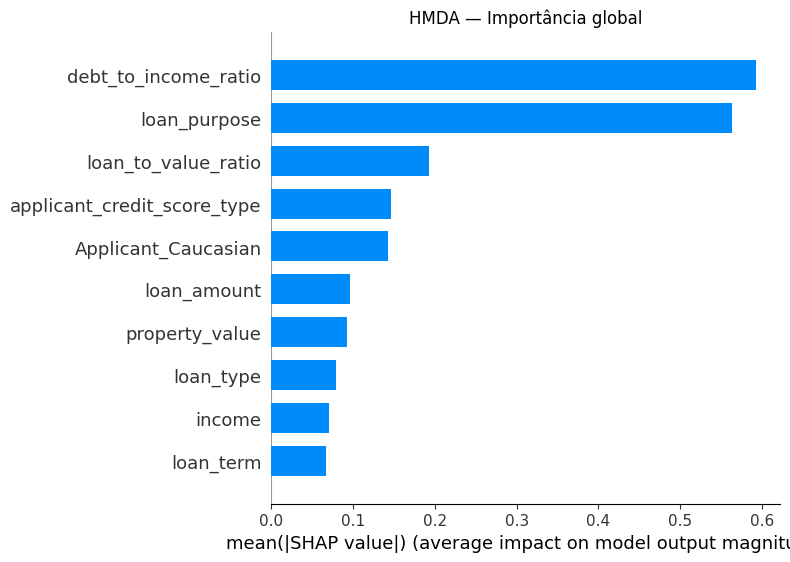

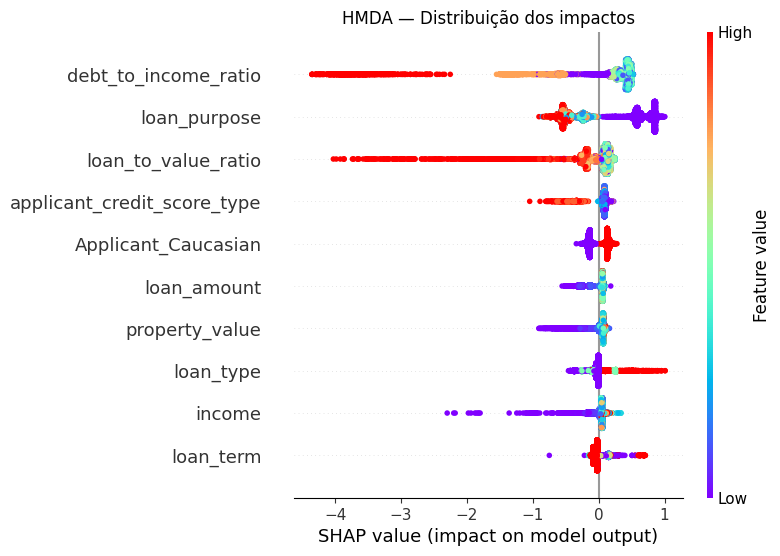

In [ ]:
import importlib
import func_aux

importlib.reload(func_aux)

from func_aux import *

explain_model(
    model,
    X_test,
    nome="HMDA",
    target_name="Aprovação",
    cmap="rainbow"
)

### Fim

In [ ]:
import sys

!"{sys.executable}" -m pip install shap